In [8]:
import pandas as pd
from sqlalchemy import create_engine
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
import platform
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import statsmodels.api as sm
import ssl
import certifi
from urllib.request import urlopen
import json
from DATA.stock_invest_function import *
import seaborn as sns
import matplotlib.pyplot as pl

In [9]:
def preprocess_quarterly_growth(df: pd.DataFrame) -> pd.DataFrame:
    """
    월별 데이터를 분기별로 집계하고, 전년 동분기 대비 성장률을 계산하는 함수
    """
    df['quarter'] = df['date'].dt.to_period('Q')
    df_quarterly = (
        df.groupby(['root_hs_code', 'quarter'])['value']
          .sum()
          .reset_index()
    )
    df_quarterly['date'] = df_quarterly['quarter'].dt.to_timestamp(how='end')
    df_quarterly.drop(columns=['quarter'], inplace=True)
    df_quarterly['date'] = pd.to_datetime(df_quarterly['date']).dt.date

    df_quarterly = df_quarterly.sort_values(['root_hs_code', 'date'])
    df_quarterly['yoy_value'] = df_quarterly.groupby('root_hs_code')['value'].shift(4)
    df_quarterly['yoy_growth'] = (
        (df_quarterly['value'] - df_quarterly['yoy_value']) / df_quarterly['yoy_value']
    ) * 100

    return df_quarterly


def create_yoy_growth_pivot(df_quarterly: pd.DataFrame,
                             start_date: str = None,
                             end_date: str = None) -> pd.DataFrame:
    """
    전년 동분기 대비 증가율을 pivot 형태로 변환하고 분석기간을 설정할 수 있는 함수
    
    Parameters:
    - df_quarterly (DataFrame): 'root_hs_code', 'date', 'yoy_growth' 포함된 데이터
    - start_date (str or None): 분석 시작일 (예: '2015-01-01')
    - end_date (str or None): 분석 종료일 (예: '2023-12-31')

    Returns:
    - pivot_df (DataFrame): 행: date, 열: root_hs_code, 값: yoy_growth
    """
    pivot_df = df_quarterly.pivot(
        index='date',
        columns='root_hs_code',
        values='yoy_growth'
    ).sort_index()

    pivot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    pivot_df.index = pd.to_datetime(pivot_df.index)

    if start_date:
        pivot_df = pivot_df[pivot_df.index >= pd.to_datetime(start_date)]
    if end_date:
        pivot_df = pivot_df[pivot_df.index <= pd.to_datetime(end_date)]

    return pivot_df

def us_trade_pivot_dataframe(df, index_col='date', column_col='hs_code', value_col='expDlr'):
    """
    주어진 DataFrame에서 피벗 테이블을 생성합니다.

    Parameters:
    - df: 원본 DataFrame
    - index_col: 피벗 테이블의 인덱스가 될 열 (기본값 'date')
    - column_col: 피벗 테이블의 컬럼이 될 열 (기본값 'hs_code')
    - value_col: 피벗 테이블의 값이 될 열 (기본값 'expDlr')

    Returns:
    - pivot_df: 피벗 테이블 형태의 DataFrame
    """
    pivot_df = df.pivot(index=index_col, columns=column_col, values=value_col)
    return pivot_df

def analyze_export_trends(pivot_df, n_recent=12, n_top=5):
    """
    수출금액 피벗 테이블을 기반으로 고점 돌파 HS Code와
    YoY 증가율 상위 HS Code를 추출하는 함수.

    inf 값은 자동으로 제외됩니다.

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (value = 수출금액)
    - n_recent: 최근 몇 개월을 기준으로 분석할지 (기본값: 12개월)
    - n_top: 상위 몇 종목을 출력할지 (기본값: 5종목)

    Returns:
    - breakout_codes: 신고점을 갱신한 HS Code 리스트
    - top_yoy_growth_df: 최근 n개월간 YoY 증가율 상위 n개 HS Code의 DataFrame
    """

    # 날짜 기준 정렬
    pivot_df = pivot_df.sort_index()

    # 최근 n개월 데이터 선택
    recent_df = pivot_df.iloc[-n_recent:]
    last_month = recent_df.index[-1]

    # 1. 신고점 돌파한 HS Code 찾기
    breakout_codes = []
    for col in recent_df.columns:
        max_before = recent_df.iloc[:-1][col].max()
        last_value = recent_df.iloc[-1][col]
        if pd.notna(last_value) and last_value > max_before:
            breakout_codes.append(col)

    # 2. 최근 n개월간 YoY 증가율 계산
    yoy_df = pivot_df.copy()
    yoy_df.index = pd.to_datetime(yoy_df.index)

    # 12개월 전 대비 YoY 변화율 (%)
    yoy_change = yoy_df.pct_change(12) * 100
    recent_yoy = yoy_change.iloc[-n_recent:]

    # 평균 YoY 성장률 계산
    mean_yoy_growth = recent_yoy.mean()

    # inf, -inf, NaN 제거
    mean_yoy_growth = mean_yoy_growth.replace([np.inf, -np.inf], np.nan).dropna()

    # 상위 n개 종목 추출
    top_yoy_growth_df = mean_yoy_growth.sort_values(ascending=False).head(n_top).reset_index()
    top_yoy_growth_df.columns = ['HS_Code', f'Mean_YoY_Growth_{n_recent}m (%)']

       # 보기 좋게 숫자 포맷팅 (소수점 2자리까지)
    colname = f'Mean_YoY_Growth_{n_recent}m (%)'
    top_yoy_growth_df[colname] = top_yoy_growth_df[colname].round(2)

    return breakout_codes, top_yoy_growth_df


def get_recent_yoy_growth(pivot_df, hs_code, n_recent=12):
    """
    특정 HS Code의 최근 n개월 YoY 수출 증가율(%)을 반환하는 함수

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (수출금액 피벗 테이블)
    - hs_code: 조회할 HS 코드 (문자열 또는 정수형)
    - n_recent: 최근 몇 개월치를 조회할지 (기본값: 12)

    Returns:
    - pandas.Series: 최근 n개월간 날짜별 YoY 증가율 (소수 둘째 자리 반올림)
    """
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'가 데이터에 없습니다.")

    # 해당 HS Code만 추출
    ts = df[hs_code]

    # YoY 변화율 계산 (%)
    yoy = ts.pct_change(12) * 100

    # 최근 n개월 가져오기
    recent_yoy = yoy.dropna().iloc[-n_recent:]

    # 소수 둘째 자리까지 반올림
    return recent_yoy.round(2)

def find_ma_golden_cross(pivot_df):
    """
    HS Code별로 3/6/12개월 이동평균을 계산하고,
    3-6개월, 3-12개월 골든크로스를 만족하는 HS Code를 반환합니다.

    Parameters:
    - pivot_df: 날짜 인덱스(date), HS Code를 열로 가진 수출금액 피벗 테이블

    Returns:
    - cross_3_6: 3개월 > 6개월 골든크로스 조건을 만족하는 HS Code 리스트
    - cross_3_12: 3개월 > 12개월 골든크로스 조건을 만족하는 HS Code 리스트
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # 이동평균 계산
    ma_3 = df.rolling(window=3).mean()
    ma_6 = df.rolling(window=6).mean()
    ma_12 = df.rolling(window=12).mean()

    # 최근 시점 (마지막 row) 기준 비교
    latest_ma_3 = ma_3.iloc[-1]
    latest_ma_6 = ma_6.iloc[-1]
    latest_ma_12 = ma_12.iloc[-1]

    # 골든크로스 조건 필터링
    cross_3_6 = latest_ma_3[latest_ma_3 > latest_ma_6].dropna().index.tolist()
    cross_3_12 = latest_ma_3[latest_ma_3 > latest_ma_12].dropna().index.tolist()

    return cross_3_6, cross_3_12

def plot_export_with_moving_averages(pivot_df, hs_code, start_date=None):
    """
    특정 HS Code의 수출금액과 3, 6, 12개월 이동평균선을 시각화하는 함수

    Parameters:
    - pivot_df: 날짜 인덱스를 가진 HS Code별 수출금액 피벗 테이블
    - hs_code: 시각화할 HS Code (문자열 또는 정수)
    - start_date: 시각화 시작 시점 (문자열 'YYYY-MM-DD' 또는 None)
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'는 데이터에 없습니다.")

    series = df[hs_code]

    # 이동평균 계산
    ma_3 = series.rolling(3).mean()
    ma_6 = series.rolling(6).mean()
    ma_12 = series.rolling(12).mean()

    # 시각화 구간 자르기 (선택사항)
    if start_date:
        series = series[series.index >= start_date]
        ma_3 = ma_3[ma_3.index >= start_date]
        ma_6 = ma_6[ma_6.index >= start_date]
        ma_12 = ma_12[ma_12.index >= start_date]

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(series, label='Monthly Export', color='black', linewidth=2)
    plt.plot(ma_3, label='3-Month MA', linestyle='--')
    plt.plot(ma_6, label='6-Month MA', linestyle='--')
    plt.plot(ma_12, label='12-Month MA', linestyle='--')

    plt.title(f'Export Trend for HS Code {hs_code}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Export Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

from datetime import datetime, date

# ============================================================================
# 이 함수만 복사해서 사용하세요!
# ============================================================================


def get_change_rate(df, target_date):
    """
    특정 날짜를 포함한 전후 12개월 expDlr 변화율 계산

    ✅ 이전 12개월: target_date를 포함한 과거 12개월
    ✅ 이후 12개월: target_date 다음 달부터 12개월

    예시:
        target_date = 2025-12-31
        이전 12개월: 2025-01-31 ~ 2025-12-31 (12개월)
        이후 12개월: 2026-01-31 ~ 2026-12-31 (12개월)
    """
    # 복사본 생성 및 인덱스 변환
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    target_date = pd.Timestamp(target_date)

    # 정렬
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()

    # ✅ 이전 12개월 (target_date 포함)
    before_end = target_date
    before_start = target_date - pd.DateOffset(months=11)

    # ✅ 이후 12개월 (target_date 다음 달부터)
    after_start = target_date + pd.DateOffset(months=1)
    after_end = target_date + pd.DateOffset(months=12)

    # 데이터 추출
    before_data = df[(df.index >= before_start) & (df.index <= before_end)]
    after_data = df[(df.index >= after_start) & (df.index <= after_end)]

    # 합계 계산
    before_sum = before_data['expDlr'].sum()
    after_sum = after_data['expDlr'].sum()

    # 변화율 계산
    change_rate = ((after_sum - before_sum) / before_sum) * 100 if before_sum != 0 else 0

    return {
        'target_date': target_date.strftime('%Y-%m-%d'),
        'before_sum': before_sum,
        'after_sum': after_sum,
        'change_rate': change_rate,
        'change_amount': after_sum - before_sum,
        'before_period': f"{before_start.strftime('%Y-%m-%d')} ~ {before_end.strftime('%Y-%m-%d')}",
        'after_period': f"{after_start.strftime('%Y-%m-%d')} ~ {after_end.strftime('%Y-%m-%d')}",
        'before_count': len(before_data),
        'after_count': len(after_data)
    }

# ============================================================================
# 사용 예제
# ============================================================================

# # 예제 데이터 (실제로는 DB에서 가져온 df_hs 사용)
# dates = pd.date_range('2023-01-31', '2027-12-31', freq='M')
# df_example = pd.DataFrame({
#     'hs_code_6d': ['854232'] * len(dates),
#     'expDlr': np.random.uniform(150000000, 250000000, len(dates)),
#     'forecast_flag': [0] * 36 + [1] * (len(dates) - 36)
# }, index=dates)
#
# print("=" * 80)
# print("예제 데이터")
# print("=" * 80)
# print(df_example.tail(15))

# ============================================================================
# 사용법 1: 단일 날짜 분석
# ============================================================================

# print("\n" + "=" * 80)
# print("사용법 1: 단일 날짜 분석")
# print("=" * 80)
#
# # 기준 날짜 지정
# target = '2025-07-31'
#
# # 변화율 계산
# result = get_change_rate(df_example, target)
#
# # 결과 출력
# print(f"\n기준 날짜: {result['target_date']}")
# print(f"\n이전 12개월 ({result['before_period']}):")
# print(f"  합계: ${result['before_sum']:,.0f}")
# print(f"\n이후 12개월 ({result['after_period']}):")
# print(f"  합계: ${result['after_sum']:,.0f}")
# print(f"\n변화율: {result['change_rate']:+.2f}%")

# ============================================================================
# 사용법 2: 여러 날짜 분석
# ============================================================================

# print("\n" + "=" * 80)
# print("사용법 2: 여러 날짜 분석")
# print("=" * 80)
#
# dates_to_analyze = ['2024-06-30', '2024-12-31', '2025-06-30']
#
# results = []
# for date in dates_to_analyze:
#     r = get_change_rate(df_example, date)
#     results.append(r)
#
# # DataFrame으로 변환
# df_results = pd.DataFrame(results)
# print("\n", df_results)

# ============================================================================
# 사용법 3: 실제 데이터에 적용
# ============================================================================
#
# print("\n" + "=" * 80)
# print("사용법 3: 실제 데이터에 적용하는 방법")
# print("=" * 80)
#
# print("""
# # 1. DB에서 데이터 로드 (이미 로드되어 있다고 가정)
# # df_hs = ...  # 특정 HS 코드 데이터
#
# # 2. 날짜가 인덱스가 아니면 설정
# if 'date' in df_hs.columns:
#     df_hs = df_hs.set_index('date')
#
# # 3. 변화율 계산
# result = get_change_rate(df_hs, '2025-07-31')
#
# # 4. 결과 확인
# print(f"변화율: {result['change_rate']:.2f}%")
# """)

# ============================================================================
# 보너스: 간단한 시각화
# ============================================================================

print("\n" + "=" * 80)
print("보너스: 간단한 시각화")
print("=" * 80)


def plot_change_analysis(df, target_date):
    """변화율 분석 시각화"""
    result = get_change_rate(df, target_date)

    # 이전/이후 데이터 추출
    target_dt = pd.to_datetime(target_date)
    before_end = target_dt - pd.DateOffset(months=1)
    before_start = target_dt - pd.DateOffset(months=12)
    after_start = target_dt + pd.DateOffset(months=1)
    after_end = target_dt + pd.DateOffset(months=12)

    before_data = df[(df.index >= before_start) & (df.index <= before_end)]
    after_data = df[(df.index >= after_start) & (df.index <= after_end)]

    # 그래프 생성
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 왼쪽: 시계열 그래프
    ax1.plot(df.index, df['expDlr'], color='gray', alpha=0.3, label='전체')
    ax1.plot(before_data.index, before_data['expDlr'],
             color='blue', linewidth=2, marker='o', label='이전 12개월')
    ax1.plot(after_data.index, after_data['expDlr'],
             color='orange', linewidth=2, marker='s', label='이후 12개월')
    ax1.axvline(x=target_dt, color='red', linestyle='--', linewidth=2, label='기준일')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('expDlr')
    ax1.set_title(f'전후 12개월 비교\n기준일: {target_date}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # 오른쪽: 막대 그래프
    categories = ['이전\n12개월', '이후\n12개월']
    values = [result['before_sum'], result['after_sum']]
    colors = ['blue', 'orange']

    bars = ax2.bar(categories, values, color=colors, alpha=0.7, width=0.5)

    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'${value/1e9:.2f}B',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 변화율 텍스트
    change_text = f"변화율: {result['change_rate']:+.1f}%"
    ax2.text(0.5, max(values)*0.5, change_text,
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
            transform=ax2.transData)

    ax2.set_ylabel('Total expDlr')
    ax2.set_title('합계 비교')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

# 시각화 실행
# fig = plot_change_analysis(df_example, '2025-07-31')
# plt.savefig('change_analysis.png', dpi=150, bbox_inches='tight')
# print("\n그래프 저장: change_analysis.png")
# plt.show()
#
# print("\n완료!")


보너스: 간단한 시각화


In [10]:
# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:  # Linux (예: Google Colab)
    plt.rc('font', family='NanumGothic')

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [11]:
# info_path = r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\US_export_HS_code_company_mapping.xlsx"
# hs_codes_info = pd.read_excel(info_path)
# hs_codes_info['hs_code'] = hs_codes_info['HS Code'].astype('str')


In [12]:
db_info = {
   'host': get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

# SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

trade_data_df = fetch_table_data(db_info, "us_trade_data")

✅ 'us_trade_data' 테이블에서 68994건의 데이터를 가져왔습니다.


In [13]:
trade_pivot_df = us_trade_pivot_dataframe(trade_data_df)

trade_pivot_df.head()

hs_code,100199,100590,100630,120190,120810,120991,121490,150710,160100,170260,...,950430,950450,950691,961900,970121,970191,970390,980110,980320,988000
date,,,,,,,,,,,,,,,,,,,,,
2013-01-31,738003507.0,447856323.0,119858959.0,3.080439e+09,153413330.0,42164715.0,114278113.0,106144315.0,45986110.0,51519619.0,...,97427364.0,71275508.0,63259622.0,63896450.0,NaN,NaN,NaN,346820713.0,72636040.0,2.491736e+09
2013-02-28,844245600.0,442869678.0,95031384.0,2.281144e+09,130171085.0,49994573.0,113295383.0,156266201.0,45073333.0,46031352.0,...,96071401.0,64200831.0,60126243.0,68193294.0,NaN,NaN,NaN,353392945.0,52013353.0,2.671081e+09
2013-03-31,936336637.0,605618304.0,110387788.0,1.154503e+09,219148293.0,49010292.0,123956385.0,53752745.0,52544748.0,57441305.0,...,121643577.0,77602297.0,67661912.0,74256440.0,NaN,NaN,NaN,366056082.0,23216995.0,2.965740e+09
2013-04-30,952592398.0,450858788.0,165179926.0,5.403578e+08,61796731.0,51143844.0,103048196.0,55517295.0,41625274.0,55411896.0,...,84541073.0,55332762.0,60755698.0,76564923.0,NaN,NaN,NaN,371444744.0,25565119.0,2.833068e+09
2013-05-31,804767583.0,427791122.0,136964132.0,3.419560e+08,67140798.0,34412604.0,108497624.0,24550746.0,52782245.0,43759965.0,...,95873268.0,57554231.0,60031936.0,72149208.0,NaN,NaN,NaN,363771617.0,48958830.0,2.973054e+09


In [14]:
trade_pivot_df.tail(10)

hs_code,100199,100590,100630,120190,120810,120991,121490,150710,160100,170260,...,950430,950450,950691,961900,970121,970191,970390,980110,980320,988000
date,,,,,,,,,,,,,,,,,,,,,
2024-12-31,449709865.0,1.244910e+09,99011512.0,3.190066e+09,84160506.0,67817336.0,104407747.0,113690543.0,75352935.0,60855868.0,...,62282849.0,104118558.0,62253404.0,70277528.0,68003960.0,269170836.0,80398213.0,700482019.0,131856357.0,5.507178e+09
2025-01-31,333370898.0,1.416530e+09,139342062.0,2.181717e+09,108296632.0,64820294.0,101377299.0,195159841.0,74579163.0,43135868.0,...,52343394.0,100817058.0,64958867.0,78727992.0,115321898.0,374924985.0,113721591.0,677485950.0,41765748.0,4.270153e+09
2025-02-28,460929948.0,1.443908e+09,131922819.0,1.303073e+09,64477500.0,63286260.0,94359139.0,113972095.0,73874707.0,44973981.0,...,75288461.0,84098207.0,58662642.0,66180184.0,95652010.0,565263432.0,122459405.0,661799149.0,105989824.0,4.736777e+09
2025-03-31,459151961.0,1.760027e+09,153615597.0,1.500642e+09,95890380.0,65709998.0,114413274.0,135996264.0,76641031.0,52950202.0,...,53012439.0,62022610.0,70114497.0,80512190.0,108320522.0,492307217.0,160070566.0,736944108.0,90718863.0,4.663327e+09
2025-04-30,553032033.0,1.796118e+09,114601338.0,9.319114e+08,84593212.0,51831208.0,97599271.0,141460127.0,82215190.0,55692406.0,...,45460714.0,91442496.0,59891059.0,74541453.0,98794551.0,353802757.0,110803877.0,777813078.0,111897579.0,5.244300e+09
2025-05-31,548615384.0,1.651699e+09,138910462.0,6.989720e+08,68223961.0,38878491.0,88401616.0,126070029.0,71908457.0,52181775.0,...,51413122.0,119057158.0,57379637.0,80483229.0,227200245.0,389823938.0,104103549.0,827999352.0,98880322.0,5.430510e+09
2025-06-30,442451179.0,1.513225e+09,104530104.0,6.536248e+08,102888662.0,39391350.0,91990747.0,19654338.0,71243512.0,54433617.0,...,54234823.0,107006768.0,54972254.0,75886592.0,407577266.0,772543269.0,170556385.0,758922755.0,85998051.0,5.577836e+09
2025-07-31,567258155.0,1.379973e+09,120940530.0,7.579368e+08,113629875.0,47059339.0,80944200.0,7093948.0,77694477.0,48097822.0,...,38756231.0,92163945.0,58141241.0,82485756.0,118677051.0,352936880.0,109228294.0,661417068.0,117092552.0,5.075378e+09
2025-08-31,650163772.0,1.408517e+09,92103945.0,1.034072e+09,58523476.0,41793881.0,89283569.0,25028133.0,75051331.0,53833598.0,...,44069832.0,144125079.0,53892249.0,76690577.0,39699958.0,390556008.0,78509923.0,794395072.0,81983686.0,5.239831e+09


In [15]:
# pivot_df = pivot_dataframe(...)  # 앞서 만든 피벗 테이블 함수로 만든 데이터프레임
num = 150
breakouts, yoy_top = analyze_export_trends(trade_pivot_df, n_recent=12, n_top=num)

print("신고점 돌파 종목 (HS Code):", breakouts)
print(f"\n최근 12개월 YoY 증가율 상위 {num}개 종목:")
print(yoy_top)

신고점 돌파 종목 (HS Code): ['100199', '220720', '260700', '271311', '271600', '293719', '300215', '300242', '300251', '310540', '381512', '382100', '390210', '392310', '392321', '490199', '630900', '711292', '711299', '711319', '711890', '740400', '840734', '841191', '841950', '841990', '850300', '854129', '854149', '854390', '880000', '880240', '900150']

최근 12개월 YoY 증가율 상위 150개 종목:
    HS_Code  Mean_YoY_Growth_12m (%)
0    150710                 44970.00
1    711590                  1712.60
2    710691                   408.55
3    840130                   173.50
4    271600                   168.07
..      ...                      ...
145  230990                     6.62
146  903190                     6.62
147  853669                     6.51
148  854430                     6.46
149  902620                     6.40

[150 rows x 2 columns]


In [9]:
# result = get_recent_yoy_growth(trade_pivot_df, hs_code='854231', n_recent=12)
# print(result)

In [16]:
trade_forecast_data_df = fetch_table_data(db_info, "us_trade_monthly_data_with_forecast")

✅ 'us_trade_monthly_data_with_forecast' 테이블에서 310634건의 데이터를 가져왔습니다.


In [17]:
trade_forecast_data_df['input_date'] = pd.to_datetime(
    trade_forecast_data_df['input_date'],  # 변환 대상
    errors='coerce',                       # 변환 불가능한 값은 NaT로 처리
    infer_datetime_format=True             # 형식 자동 추론 (속도 향상)
)

In [18]:
sample_df = trade_forecast_data_df[trade_forecast_data_df['input_date']== '2025-11-05']

len(sample_df['hs_code_6d'].unique().tolist())

478

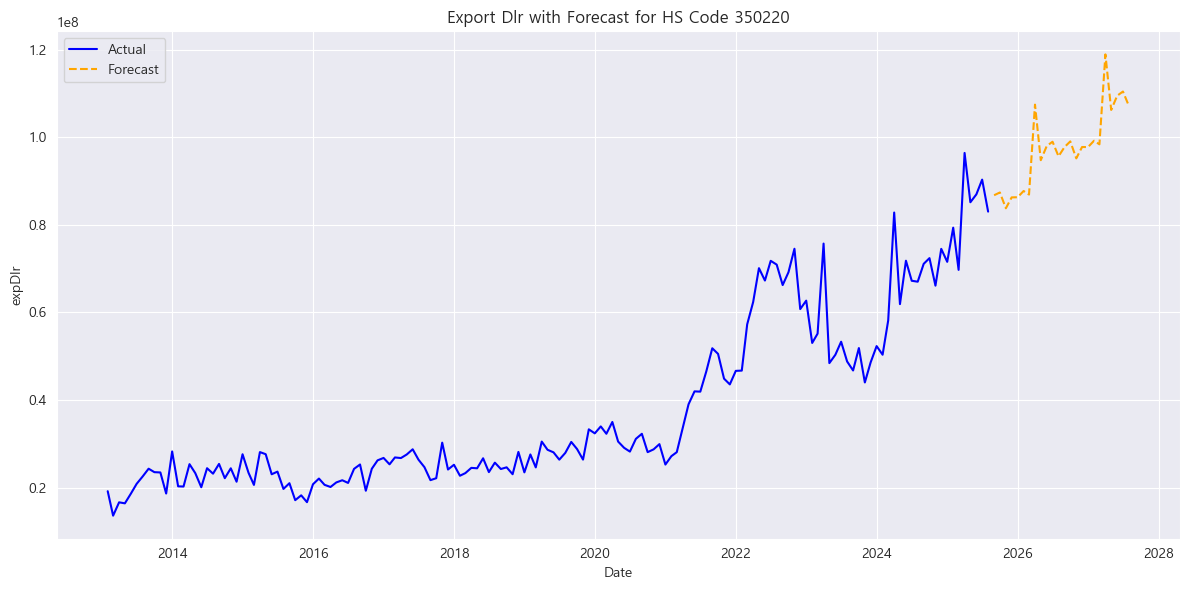

In [20]:
trade_forecast_data_re = trade_forecast_data_df.set_index('date')

df = trade_forecast_data_re
# trade_forecast_data_re[trade_forecast_data_re['hs_code_6d'] == hs_code][['expDlr']].plot()

# 📌 특정 HS CODE 지정
target_hs_code = '350220'

# 해당 HS CODE 데이터만 선택
df_hs = df[df['hs_code_6d'] == target_hs_code]

# 실데이터와 예측데이터 분리
actual_df = df_hs[(df_hs['forecast_flag'] == 0) & (df_hs['input_date'] == '2025-12-13')]
forecast_df = df_hs[(df_hs['forecast_flag'] == 1) & (df_hs['input_date'] == '2025-12-13')]

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_df.index, actual_df['expDlr'], label='Actual', linestyle='-', color='blue')
plt.plot(forecast_df.index, forecast_df['expDlr'], label='Forecast', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('expDlr')
plt.title(f'Export Dlr with Forecast for HS Code {target_hs_code}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
after_df_hs = df_hs[df_hs['input_date'] == '2025-11-05']

target = '2025-07-31'

# 변화율 계산
result = get_change_rate(after_df_hs, target)

# 결과 출력
print(f"\n기준 날짜: {result['target_date']}")
print(f"\n이전 12개월 ({result['before_period']}):")
print(f"  합계: ${result['before_sum']:,.0f}")
print(f"\n이후 12개월 ({result['after_period']}):")
print(f"  합계: ${result['after_sum']:,.0f}")
print(f"\n변화율: {result['change_rate']:+.2f}%")


기준 날짜: 2025-07-31

이전 12개월 (2024-08-31 ~ 2025-07-31):
  합계: $946,792,300

이후 12개월 (2025-08-31 ~ 2026-07-31):
  합계: $1,100,264,700

변화율: +16.21%


In [24]:
after_df_hs = df_hs[df_hs['input_date'] == '2025-12-13']

target = '2025-09-30'

# 변화율 계산
result = get_change_rate(after_df_hs, target)

# 결과 출력
print(f"\n기준 날짜: {result['target_date']}")
print(f"\n이전 12개월 ({result['before_period']}):")
print(f"  합계: ${result['before_sum']:,.0f}")
print(f"\n이후 12개월 ({result['after_period']}):")
print(f"  합계: ${result['after_sum']:,.0f}")
print(f"\n변화율: {result['change_rate']:+.2f}%")


기준 날짜: 2025-09-30

이전 12개월 (2024-10-30 ~ 2025-09-30):
  합계: $977,469,200

이후 12개월 (2025-10-30 ~ 2026-09-30):
  합계: $1,122,941,900

변화율: +14.88%


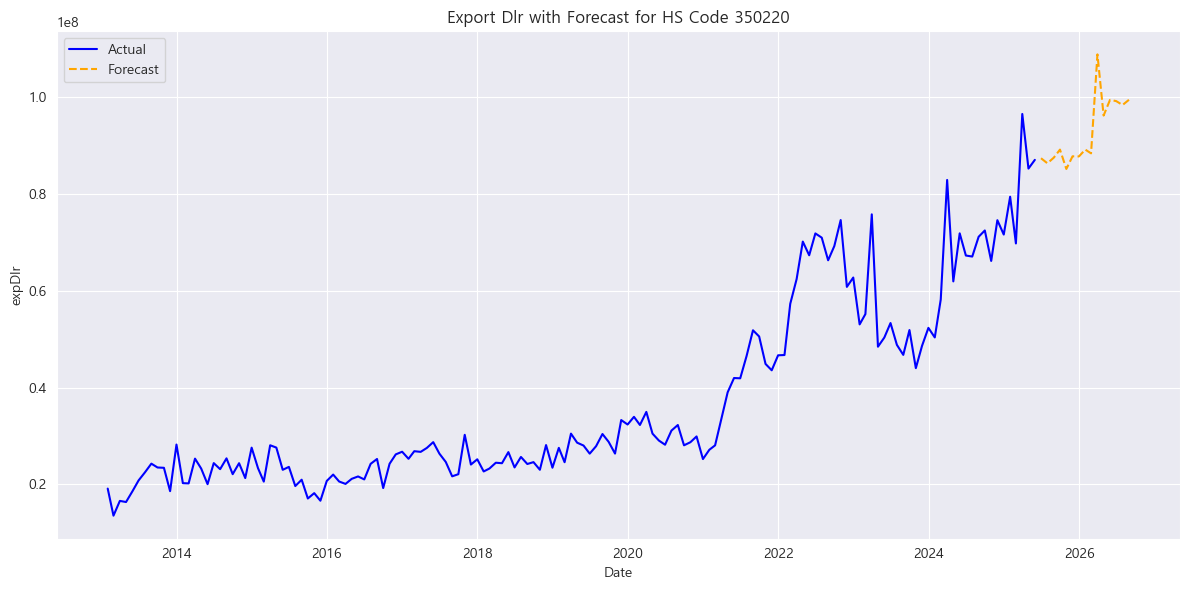

In [68]:
trade_forecast_data_re = trade_forecast_data_df.set_index('date')

df = trade_forecast_data_re
# trade_forecast_data_re[trade_forecast_data_re['hs_code_6d'] == hs_code][['expDlr']].plot()

# 📌 특정 HS CODE 지정
target_hs_code = target_hs_code

# 해당 HS CODE 데이터만 선택
df_hs = df[df['hs_code_6d'] == target_hs_code]
df_hs = df_hs.sort_index()

# 실데이터와 예측데이터 분리
actual_df = df_hs[(df_hs['forecast_flag'] == 0) & (df_hs['input_date'] == '2025-10-20')]
forecast_df = df_hs[(df_hs['forecast_flag'] == 1) & (df_hs['input_date'] == '2025-10-20')]

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_df.index, actual_df['expDlr'], label='Actual', linestyle='-', color='blue')
plt.plot(forecast_df.index, forecast_df['expDlr'], label='Forecast', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('expDlr')
plt.title(f'Export Dlr with Forecast for HS Code {target_hs_code}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
pre_df = df_hs[df_hs['input_date'] == '2025-10-20']

# 변화율 계산
pre_result = get_change_rate(pre_df, target)

# 결과 출력
print(f"\n기준 날짜: {pre_result['target_date']}")
print(f"\n이전 12개월 ({pre_result['before_period']}):")
print(f"  합계: ${pre_result['before_sum']:,.0f}")
print(f"\n이후 12개월 ({pre_result['after_period']}):")
print(f"  합계: ${pre_result['after_sum']:,.0f}")
print(f"\n변화율: {pre_result['change_rate']:+.2f}%")




기준 날짜: 2025-07-31

이전 12개월 (2024-08-31 ~ 2025-07-31):
  합계: $946,981,100

이후 12개월 (2025-08-31 ~ 2026-07-31):
  합계: $1,116,001,600

변화율: +17.85%


In [50]:
import pandas as pd

def make_forecast_pivot_by_created_at(
    df: pd.DataFrame,
    created_at_date: str,
    value_col: str = "expDlr"
) -> pd.DataFrame:
    """
    created_at 날짜 + forecast_flag=1 필터 후
    index = date
    columns = hs_code_6d
    values = expDlr
    """

    data = df.copy()

    # -----------------------------
    # 1. date 처리 (index / column 자동)
    # -----------------------------
    if "date" in data.columns:
        data["date"] = pd.to_datetime(data["date"])
        data = data.set_index("date")
    else:
        # 이미 index인 경우
        data.index = pd.to_datetime(data.index)
        data.index.name = "date"

    # -----------------------------
    # 2. created_at 처리
    # -----------------------------
    data["created_at"] = pd.to_datetime(data["created_at"])
    target_date = pd.to_datetime(created_at_date).date()

    data = data[
        (data["created_at"].dt.date == target_date) &
        (data["forecast_flag"] == 1)
    ]

    if data.empty:
        raise ValueError("조건에 해당하는 데이터가 없습니다.")

    # -----------------------------
    # 3. value 컬럼 확인 (expLlr 오타 방어)
    # -----------------------------
    if value_col not in data.columns:
        if "expDlr" in data.columns:
            value_col = "expDlr"
        else:
            raise KeyError("expDlr / expLlr 컬럼을 찾을 수 없습니다.")

    # -----------------------------
    # 4. Pivot
    # -----------------------------
    pivot_df = (
        data
        .pivot_table(
            index=data.index,
            columns="hs_code_6d",
            values=value_col,
            aggfunc="sum"
        )
        .sort_index()
    )

    return pivot_df


def top_n_hs_by_growth(
    pivot_df: pd.DataFrame,
    start_date: str,
    end_date: str,
    n: int = 20,
    method: str = "nearest_in_range"  # "exact"도 가능
) -> pd.DataFrame:
    """
    pivot_df: index=date, columns=hs_code_6d, values=expDlr 형태의 DataFrame
    start_date, end_date: 'YYYY-MM-DD'
    n: 상위 n개 hs_code_6d 추출
    method:
      - "nearest_in_range": start_date 이상 첫 관측치, end_date 이하 마지막 관측치 사용(권장)
      - "exact": start_date, end_date가 index에 정확히 있어야 함
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)

    s = pd.to_datetime(start_date)
    e = pd.to_datetime(end_date)
    if s > e:
        raise ValueError("start_date must be <= end_date")

    if method == "exact":
        if s not in df.index or e not in df.index:
            raise KeyError("start_date 또는 end_date가 index에 없습니다. method='nearest_in_range'를 사용하세요.")
        start_row = df.loc[s]
        end_row = df.loc[e]

    elif method == "nearest_in_range":
        # start_date 이상에서 가장 빠른 날짜, end_date 이하에서 가장 늦은 날짜
        df_sub = df.loc[(df.index >= s) & (df.index <= e)]
        if df_sub.empty:
            raise ValueError("해당 기간에 데이터가 없습니다. 날짜 범위를 확인하세요.")

        s_idx = df_sub.index.min()
        e_idx = df_sub.index.max()

        start_row = df.loc[s_idx]
        end_row = df.loc[e_idx]
    else:
        raise ValueError("method는 'nearest_in_range' 또는 'exact'만 가능합니다.")

    # 증가율 계산: (end/start)-1
    # start 또는 end가 NaN이거나 start==0인 경우 제외
    valid = (~start_row.isna()) & (~end_row.isna()) & (start_row != 0)
    growth = (end_row[valid] / start_row[valid]) - 1

    result = pd.DataFrame({
        "hs_code_6d": growth.index,
        "start_value": start_row[valid].values,
        "end_value": end_row[valid].values,
        "growth_rate": growth.values
    }).sort_values("growth_rate", ascending=False)

    return result.head(n).reset_index(drop=True)

In [51]:
trade_forecast_data_re

,hs_code_6d,expDlr,forecast,quarter,input_date,forecast_flag,created_at
date,,,,,,,
2025-07-31,851762,2.146230e+09,0.0,2025Q3,2025-10-09,0,2025-09-02 17:14:48
2025-08-31,851762,2.218300e+09,1.0,2025Q3,2025-01-01,0,2025-09-02 17:14:48
2025-09-30,851762,2.062910e+09,1.0,2025Q3,2025-01-01,0,2025-09-02 17:14:48
2025-10-31,851762,2.246780e+09,1.0,2025Q4,2025-01-01,0,2025-09-02 17:14:48
2025-11-30,851762,2.100540e+09,1.0,2025Q4,2025-01-01,0,2025-09-02 17:14:48
...,...,...,...,...,...,...,...
2027-03-31,988000,5.828460e+09,NaN,2027Q1,2025-12-13,1,2025-12-13 13:49:24
2027-04-30,988000,6.199400e+09,NaN,2027Q2,2025-12-13,1,2025-12-13 13:49:24
2027-05-31,988000,6.358660e+09,NaN,2027Q2,2025-12-13,1,2025-12-13 13:49:24


In [52]:
pivot_df = make_forecast_pivot_by_created_at(
    trade_forecast_data_re,
    created_at_date="2025-12-13"
)

print(pivot_df.tail())

hs_code_6d       100199        100590       100630        120190       120810  \
date                                                                            
2027-03-31  592936000.0  1.943820e+09   30367500.0  1.506720e+09  154911000.0   
2027-04-30  653415000.0  1.981580e+09  245188000.0  1.068560e+09  139477000.0   
2027-05-31  614855000.0  1.990220e+09   56946900.0  8.391820e+08  129573000.0   
2027-06-30  561247000.0  1.729680e+09  -22197400.0  8.061630e+08  138210000.0   
2027-07-31  606386000.0  1.583490e+09   44361900.0  9.127120e+08  129698000.0   

hs_code_6d      120991      121490      150710      160100      170260  ...  \
date                                                                    ...   
2027-03-31  68324400.0  84893200.0  91439400.0  80442000.0  50357100.0  ...   
2027-04-30  54499600.0  76288000.0  73220900.0  80422500.0  51640600.0  ...   
2027-05-31  47201500.0  72216500.0  70498600.0  80672500.0  53668700.0  ...   
2027-06-30  50127200.0  63903300.0  4

In [53]:
pivot_df

hs_code_6d,100199,100590,100630,120190,120810,120991,121490,150710,160100,170260,...,940290,940320,950300,950430,950450,950691,961900,980110,980320,988000
date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,661462000.0,1.230380e+09,-179929000.0,9.263090e+08,93881800.0,45330800.0,85567600.0,13217000.0,73460300.0,48416200.0,...,56694900.0,66345100.0,118415000.0,46230400.0,112438000.0,60663500.0,81251800.0,746219000.0,127472000.0,5.382690e+09
2025-09-30,670969000.0,1.106360e+09,-552695000.0,1.355380e+09,109861000.0,48310200.0,86139400.0,17199300.0,69442500.0,47842200.0,...,64302400.0,63718500.0,124373000.0,48166400.0,164828000.0,60432000.0,78170200.0,699857000.0,119539000.0,5.214090e+09
2025-10-31,422813000.0,1.081450e+09,885444000.0,4.021620e+09,115793000.0,54687100.0,89798900.0,25956900.0,74741900.0,43681400.0,...,66490300.0,69514300.0,142334000.0,47082400.0,207035000.0,66531300.0,76763300.0,766304000.0,108005000.0,5.336000e+09
2025-11-30,394114000.0,1.200330e+09,-128374000.0,4.152060e+09,137998000.0,58325900.0,87822000.0,51057800.0,74857000.0,50592000.0,...,64142200.0,65389700.0,126852000.0,55847700.0,179112000.0,70220300.0,74063600.0,699225000.0,133177000.0,5.041080e+09
2025-12-31,481897000.0,1.359630e+09,-529758000.0,3.079000e+09,133159000.0,67748900.0,83222200.0,65847700.0,73937500.0,45725400.0,...,65416200.0,57760100.0,102793000.0,52116500.0,128889000.0,66850800.0,75975500.0,732027000.0,113439000.0,6.043100e+09
2026-01-31,484821000.0,1.450820e+09,45553300.0,2.543920e+09,152742000.0,64564800.0,71033900.0,93087300.0,72608500.0,45302300.0,...,54114200.0,58231700.0,87577500.0,41989400.0,106051000.0,65450100.0,79721000.0,684037000.0,76548600.0,4.832220e+09
2026-02-28,552930000.0,1.539940e+09,169342000.0,1.679670e+09,123028000.0,63550500.0,74709000.0,77262900.0,71167600.0,43774800.0,...,61585300.0,59132400.0,88352200.0,53384000.0,106882000.0,62715100.0,77397800.0,692458000.0,104279000.0,5.277850e+09
2026-03-31,551283000.0,1.855350e+09,36071700.0,1.469010e+09,139357000.0,66233700.0,94785100.0,88407700.0,77227400.0,48284600.0,...,78738500.0,67408200.0,92832700.0,49487800.0,101125000.0,71386700.0,83962000.0,765164000.0,112224000.0,5.284110e+09
2026-04-30,617540000.0,1.892840e+09,239485000.0,9.903150e+08,124327000.0,52397500.0,84907000.0,70340800.0,78281700.0,49568300.0,...,65760900.0,64921700.0,86222800.0,37066000.0,109088000.0,63240600.0,78294100.0,742596000.0,124179000.0,5.724600e+09


In [56]:
pivot_df2 = make_forecast_pivot_by_created_at(
    trade_forecast_data_re,
    created_at_date="2025-11-05"
)

print(pivot_df2.head())

hs_code_6d       100199        100590       100630        120190       120810  \
date                                                                            
2025-08-31  661462000.0  1.230380e+09 -179929000.0  9.263090e+08   93881800.0   
2025-09-30  670969000.0  1.106360e+09 -552695000.0  1.355380e+09  109861000.0   
2025-10-31  422813000.0  1.081450e+09  885444000.0  4.021620e+09  115793000.0   
2025-11-30  394114000.0  1.200330e+09 -128374000.0  4.152060e+09  137998000.0   
2025-12-31  481897000.0  1.359630e+09 -529758000.0  3.079000e+09  133159000.0   

hs_code_6d      120991      121490      150710      160100      170260  ...  \
date                                                                    ...   
2025-08-31  45330800.0  85567600.0  13217000.0  73460300.0  48416200.0  ...   
2025-09-30  48310200.0  86139400.0  17199300.0  69442500.0  47842200.0  ...   
2025-10-31  54687100.0  89798900.0  25956900.0  74741900.0  43681400.0  ...   
2025-11-30  58325900.0  87822000.0  5

In [55]:
pivot_df2

hs_code_6d,100199,100590,100630,120190,120810,120991,121490,150710,160100,170260,...,940290,940320,950300,950430,950450,950691,961900,980110,980320,988000
date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,661462000.0,1.230380e+09,-179929000.0,9.263090e+08,93881800.0,45330800.0,85567600.0,13217000.0,73460300.0,48416200.0,...,56694900.0,66345100.0,118415000.0,46230400.0,112438000.0,60663500.0,81251800.0,746219000.0,127472000.0,5.382690e+09
2025-09-30,670969000.0,1.106360e+09,-552695000.0,1.355380e+09,109861000.0,48310200.0,86139400.0,17199300.0,69442500.0,47842200.0,...,64302400.0,63718500.0,124373000.0,48166400.0,164828000.0,60432000.0,78170200.0,699857000.0,119539000.0,5.214090e+09
2025-10-31,422813000.0,1.081450e+09,885444000.0,4.021620e+09,115793000.0,54687100.0,89798900.0,25956900.0,74741900.0,43681400.0,...,66490300.0,69514300.0,142334000.0,47082400.0,207035000.0,66531300.0,76763300.0,766304000.0,108005000.0,5.336000e+09
2025-11-30,394114000.0,1.200330e+09,-128374000.0,4.152060e+09,137998000.0,58325900.0,87822000.0,51057800.0,74857000.0,50592000.0,...,64142200.0,65389700.0,126852000.0,55847700.0,179112000.0,70220300.0,74063600.0,699225000.0,133177000.0,5.041080e+09
2025-12-31,481897000.0,1.359630e+09,-529758000.0,3.079000e+09,133159000.0,67748900.0,83222200.0,65847700.0,73937500.0,45725400.0,...,65416200.0,57760100.0,102793000.0,52116500.0,128889000.0,66850800.0,75975500.0,732027000.0,113439000.0,6.043100e+09
2026-01-31,484821000.0,1.450820e+09,45553300.0,2.543920e+09,152742000.0,64564800.0,71033900.0,93087300.0,72608500.0,45302300.0,...,54114200.0,58231700.0,87577500.0,41989400.0,106051000.0,65450100.0,79721000.0,684037000.0,76548600.0,4.832220e+09
2026-02-28,552930000.0,1.539940e+09,169342000.0,1.679670e+09,123028000.0,63550500.0,74709000.0,77262900.0,71167600.0,43774800.0,...,61585300.0,59132400.0,88352200.0,53384000.0,106882000.0,62715100.0,77397800.0,692458000.0,104279000.0,5.277850e+09
2026-03-31,551283000.0,1.855350e+09,36071700.0,1.469010e+09,139357000.0,66233700.0,94785100.0,88407700.0,77227400.0,48284600.0,...,78738500.0,67408200.0,92832700.0,49487800.0,101125000.0,71386700.0,83962000.0,765164000.0,112224000.0,5.284110e+09
2026-04-30,617540000.0,1.892840e+09,239485000.0,9.903150e+08,124327000.0,52397500.0,84907000.0,70340800.0,78281700.0,49568300.0,...,65760900.0,64921700.0,86222800.0,37066000.0,109088000.0,63240600.0,78294100.0,742596000.0,124179000.0,5.724600e+09


In [32]:
top_export_df = top_n_hs_by_growth(
    pivot_df=forecast_df,
    start_date="2026-01-31",
    end_date="2026-12-31",
    n=50
)

print(top_export_df)

   hs_code_6d   start_value     end_value  growth_rate
0      850790 -2.504490e+07 -1.567700e+08     5.259558
1      860210  2.590780e+07  5.322210e+07     1.054289
2      903141  2.474480e+08  4.297020e+08     0.736535
3      841182  1.469910e+08  2.500070e+08     0.700832
4      870340  1.945340e+08  3.052380e+08     0.569073
5      870324  6.587430e+08  1.030670e+09     0.564601
6      980320  7.654860e+07  1.197020e+08     0.563739
7      870332  6.936820e+07  1.063170e+08     0.532648
8      260700  4.961910e+07  7.524910e+07     0.516535
9      903082  1.017070e+08  1.530760e+08     0.505068
10     852349  5.714400e+07  8.575050e+07     0.500604
11     840130  1.975270e+07  2.932640e+07     0.484678
12     310559  4.615610e+07  6.600440e+07     0.430026
13     200819  6.451450e+07  9.200350e+07     0.426090
14     902219  2.672350e+07  3.776100e+07     0.413026
15     852610  8.270920e+07  1.164850e+08     0.408368
16     847150  2.804890e+09  3.891920e+09     0.387548
17     294

In [33]:
past_month_forecast_df = make_expDlr_pivot(
    pre_df = trade_forecast_data_re,
    input_date = "2025-11-05"
)

last_month_top_export_df = top_n_hs_by_growth(
    pivot_df = past_month_forecast_df,
    start_date = "2026-01-31",
    end_date = "2026-12-31",
    n=50
)

print(last_month_top_export_df)

   hs_code_6d   start_value     end_value  growth_rate
0      850790 -2.504490e+07 -1.567700e+08     5.259558
1      860210  2.590780e+07  5.322210e+07     1.054289
2      903141  2.474480e+08  4.297020e+08     0.736535
3      841182  1.469910e+08  2.500070e+08     0.700832
4      870340  1.945340e+08  3.052380e+08     0.569073
5      870324  6.587430e+08  1.030670e+09     0.564601
6      980320  7.654860e+07  1.197020e+08     0.563739
7      870332  6.936820e+07  1.063170e+08     0.532648
8      260700  4.961910e+07  7.524910e+07     0.516535
9      903082  1.017070e+08  1.530760e+08     0.505068
10     852349  5.714400e+07  8.575050e+07     0.500604
11     840130  1.975270e+07  2.932640e+07     0.484678
12     310559  4.615610e+07  6.600440e+07     0.430026
13     200819  6.451450e+07  9.200350e+07     0.426090
14     902219  2.672350e+07  3.776100e+07     0.413026
15     852610  8.270920e+07  1.164850e+08     0.408368
16     847150  2.804890e+09  3.891920e+09     0.387548
17     294

In [35]:
past_month_forecast_df.tail(10)

hs_code_6d,100199,100590,100630,120190,120810,120991,121490,150710,160100,170260,...,950430,950450,950691,961900,970121,970191,970390,980110,980320,988000
date,,,,,,,,,,,,,,,,,,,,,
2026-10-31,457927000.0,1.194340e+09,891147000.0,4.009630e+09,129271000.0,57143200.0,79738900.0,34405400.0,77703500.0,45650500.0,...,44603800.0,212169000.0,69942200.0,79613600.0,NaN,NaN,NaN,799632000.0,114268000.0,5.854490e+09
2026-11-30,432589000.0,1.293480e+09,-134078000.0,4.057880e+09,149480000.0,60260800.0,77998100.0,57038400.0,77370900.0,52693600.0,...,50950700.0,184202000.0,72624700.0,76913900.0,NaN,NaN,NaN,732553000.0,139440000.0,5.579710e+09
2026-12-31,510968000.0,1.451830e+09,-524052000.0,3.080970e+09,150380000.0,69682300.0,73044600.0,70415600.0,76676500.0,47789400.0,...,48931700.0,133954000.0,70608000.0,78825800.0,NaN,NaN,NaN,765355000.0,119702000.0,6.545440e+09
2027-01-31,538871000.0,1.527560e+09,39848800.0,2.758910e+09,168302000.0,66448500.0,59175500.0,96846700.0,75215600.0,47377000.0,...,38751800.0,111104000.0,67841200.0,82571300.0,NaN,NaN,NaN,717366000.0,82811800.0,5.347510e+09
2027-02-28,594553000.0,1.628540e+09,175046000.0,1.901140e+09,141751000.0,65572300.0,64813100.0,80559500.0,73599800.0,45846400.0,...,46899900.0,111929000.0,66291000.0,80248200.0,NaN,NaN,NaN,725786000.0,110542000.0,5.782740e+09
2027-03-31,592936000.0,1.943820e+09,30367500.0,1.506720e+09,154911000.0,68324400.0,84893200.0,91439400.0,80442000.0,50357100.0,...,48169800.0,106168000.0,74037600.0,86812300.0,NaN,NaN,NaN,798492000.0,118487000.0,5.828460e+09
2027-04-30,653415000.0,1.981580e+09,245188000.0,1.068560e+09,139477000.0,54499600.0,76288000.0,73220900.0,80422500.0,51640600.0,...,34379200.0,114129000.0,66582700.0,81144500.0,NaN,NaN,NaN,775924000.0,130442000.0,6.199400e+09
2027-05-31,614855000.0,1.990220e+09,56946900.0,8.391820e+08,129573000.0,47201500.0,72216500.0,70498600.0,80672500.0,53668700.0,...,39416100.0,108977000.0,64454000.0,86997000.0,NaN,NaN,NaN,794268000.0,109203000.0,6.358660e+09
2027-06-30,561247000.0,1.729680e+09,-22197400.0,8.061630e+08,138210000.0,50127200.0,63903300.0,45027400.0,79973900.0,55292800.0,...,46180000.0,108979000.0,64083600.0,87091900.0,NaN,NaN,NaN,787889000.0,101756000.0,6.484370e+09


In [37]:
forecast_df.tail(24)

hs_code_6d,100199,100590,100630,120190,120810,120991,121490,150710,160100,170260,...,950430,950450,950691,961900,970121,970191,970390,980110,980320,988000
date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,661462000.0,1.230380e+09,-179929000.0,9.263090e+08,93881800.0,45330800.0,85567600.0,13217000.0,73460300.0,48416200.0,...,46230400.0,112438000.0,60663500.0,81251800.0,NaN,NaN,NaN,746219000.0,127472000.0,5.382690e+09
2025-09-30,670969000.0,1.106360e+09,-552695000.0,1.355380e+09,109861000.0,48310200.0,86139400.0,17199300.0,69442500.0,47842200.0,...,48166400.0,164828000.0,60432000.0,78170200.0,NaN,NaN,NaN,699857000.0,119539000.0,5.214090e+09
2025-10-31,422813000.0,1.081450e+09,885444000.0,4.021620e+09,115793000.0,54687100.0,89798900.0,25956900.0,74741900.0,43681400.0,...,47082400.0,207035000.0,66531300.0,76763300.0,NaN,NaN,NaN,766304000.0,108005000.0,5.336000e+09
2025-11-30,394114000.0,1.200330e+09,-128374000.0,4.152060e+09,137998000.0,58325900.0,87822000.0,51057800.0,74857000.0,50592000.0,...,55847700.0,179112000.0,70220300.0,74063600.0,NaN,NaN,NaN,699225000.0,133177000.0,5.041080e+09
2025-12-31,481897000.0,1.359630e+09,-529758000.0,3.079000e+09,133159000.0,67748900.0,83222200.0,65847700.0,73937500.0,45725400.0,...,52116500.0,128889000.0,66850800.0,75975500.0,NaN,NaN,NaN,732027000.0,113439000.0,6.043100e+09
2026-01-31,484821000.0,1.450820e+09,45553300.0,2.543920e+09,152742000.0,64564800.0,71033900.0,93087300.0,72608500.0,45302300.0,...,41989400.0,106051000.0,65450100.0,79721000.0,NaN,NaN,NaN,684037000.0,76548600.0,4.832220e+09
2026-02-28,552930000.0,1.539940e+09,169342000.0,1.679670e+09,123028000.0,63550500.0,74709000.0,77262900.0,71167600.0,43774800.0,...,53384000.0,106882000.0,62715100.0,77397800.0,NaN,NaN,NaN,692458000.0,104279000.0,5.277850e+09
2026-03-31,551283000.0,1.855350e+09,36071700.0,1.469010e+09,139357000.0,66233700.0,94785100.0,88407700.0,77227400.0,48284600.0,...,49487800.0,101125000.0,71386700.0,83962000.0,NaN,NaN,NaN,765164000.0,112224000.0,5.284110e+09
2026-04-30,617540000.0,1.892840e+09,239485000.0,9.903150e+08,124327000.0,52397500.0,84907000.0,70340800.0,78281700.0,49568300.0,...,37066000.0,109088000.0,63240600.0,78294100.0,NaN,NaN,NaN,742596000.0,124179000.0,5.724600e+09


In [38]:
# -*- coding: utf-8 -*-
from __future__ import annotations
import pandas as pd
from sqlalchemy import create_engine, text
from typing import Optional, Union, List, Dict, Any

FORECAST_COL = "forecast_flag"  # ← 확정

def make_engine(db_info: Dict[str, Any]):
    uri = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info.get('port', 3306))}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(uri, pool_pre_ping=True)

def _to_hs6(x: Union[str, int]) -> str:
    s = str(x).strip()
    return f"{int(s):06d}" if s.isdigit() else s[:6]

# 1) input_date 목록/최신값 -------------------------------------------------------
def get_available_input_dates(
    db_info: Dict[str, Any],
    table_name: str = "us_trade_monthly_data_with_forecast"
) -> List[pd.Timestamp]:
    eng = make_engine(db_info)
    q = text(f"""
        SELECT DISTINCT input_date
        FROM {table_name}
        WHERE input_date IS NOT NULL
        ORDER BY input_date
    """)
    df = pd.read_sql(q, eng, parse_dates=["input_date"])
    return df["input_date"].tolist()

def get_latest_input_date(
    db_info: Dict[str, Any],
    table_name: str = "us_trade_monthly_data_with_forecast"
) -> Optional[pd.Timestamp]:
    dates = get_available_input_dates(db_info, table_name)
    return dates[-1] if dates else None

# 공통 스냅샷 로더 --------------------------------------------------------------
def _load_snapshot(
    db_info: Dict[str, Any],
    input_date: Union[str, pd.Timestamp],
    hs_code: Optional[Union[str, int]] = None,
    table_name: str = "us_trade_monthly_data_with_forecast"
) -> pd.DataFrame:
    params = {"input_date": pd.to_datetime(input_date).date()}
    cond = "WHERE `input_date` = :input_date"
    if hs_code is not None:
        params["hs"] = _to_hs6(hs_code)
        cond += " AND `hs_code_6d` = :hs"

    q = text(f"""
        SELECT `hs_code_6d`, `date`, `expDlr`, `{FORECAST_COL}` AS forecast_std,
               `quarter`, `input_date`
        FROM `{table_name}`
        {cond}
        ORDER BY `hs_code_6d`, `date`
    """)
    eng = make_engine(db_info)
    df = pd.read_sql(q, eng, params=params, parse_dates=["date", "input_date"])
    return df

def _growth_first_to_last(series: pd.Series) -> Optional[float]:
    s = series.dropna()
    if len(s) < 2:
        return None
    first_val, last_val = float(s.iloc[0]), float(s.iloc[-1])
    if first_val == 0:
        return None
    return (last_val - first_val) / abs(first_val) * 100.0

# 2) 특정 hs_code + input_date 성장률 -------------------------------------------
def growth_for_hs_at_input_date(
    db_info: Dict[str, Any],
    hs_code: Union[str, int],
    input_date: Union[str, pd.Timestamp],
    table_name: str = "us_trade_monthly_data_with_forecast"
) -> Dict[str, Any]:
    hs = _to_hs6(hs_code)
    snap = _load_snapshot(db_info, input_date, hs, table_name)
    snap = snap[snap["forecast_std"] == 1].sort_values("date")

    out = {
        "hs_code_6d": hs,
        "input_date": pd.to_datetime(input_date),
        "count_points": int(snap.shape[0]),
        "first_date": None, "last_date": None,
        "first_expDlr": None, "last_expDlr": None,
        "growth_pct": None,
    }
    if snap.empty:
        return out

    out["first_date"]   = snap["date"].iloc[0]
    out["last_date"]    = snap["date"].iloc[-1]
    out["first_expDlr"] = float(snap["expDlr"].iloc[0]) if pd.notna(snap["expDlr"].iloc[0]) else None
    out["last_expDlr"]  = float(snap["expDlr"].iloc[-1]) if pd.notna(snap["expDlr"].iloc[-1]) else None
    out["growth_pct"]   = _growth_first_to_last(snap["expDlr"])
    return out

# 3) input_date 스냅샷 전체 랭킹 -------------------------------------------------
def rank_hs_by_growth(
    db_info: Dict[str, Any],
    input_date: Union[str, pd.Timestamp],
    n: int = 20,
    ascending: bool = False,
    min_points: int = 2,
    table_name: str = "us_trade_monthly_data_with_forecast"
) -> pd.DataFrame:
    snap = _load_snapshot(db_info, input_date, hs_code=None, table_name=table_name)
    snap = snap[snap["forecast_std"] == 1].sort_values(["hs_code_6d", "date"])

    rows = []
    for hs, g in snap.groupby("hs_code_6d", sort=False):
        g = g.sort_values("date")
        if g["expDlr"].notna().sum() < min_points:
            continue
        gr = _growth_first_to_last(g["expDlr"])
        if gr is None:
            continue
        rows.append({
            "hs_code_6d": hs,
            "growth_pct": gr,
            "count_points": int(g.shape[0]),
            "first_date": g["date"].iloc[0],
            "last_date": g["date"].iloc[-1],
            "first_expDlr": float(g["expDlr"].iloc[0]) if pd.notna(g["expDlr"].iloc[0]) else None,
            "last_expDlr": float(g["expDlr"].iloc[-1]) if pd.notna(g["expDlr"].iloc[-1]) else None,
        })
    if not rows:
        return pd.DataFrame(columns=["rank","hs_code_6d","growth_pct","count_points","first_date","last_date","first_expDlr","last_expDlr"])

    res = pd.DataFrame(rows).sort_values("growth_pct", ascending=ascending).head(n).reset_index(drop=True)
    res.insert(0, "rank", res.index + 1)
    return res

# 4) 두 input_date 비교(동일 hs_code) -------------------------------------------
def compare_two_input_dates_for_hs(
    db_info: Dict[str, Any],
    hs_code: Union[str, int],
    input_date_old: Union[str, pd.Timestamp],
    input_date_new: Union[str, pd.Timestamp],
    table_name: str = "us_trade_monthly_data_with_forecast"
) -> Dict[str, Any]:
    hs = _to_hs6(hs_code)
    a = _load_snapshot(db_info, input_date_old, hs, table_name)
    b = _load_snapshot(db_info, input_date_new, hs, table_name)
    a = a[a["forecast_std"] == 1].sort_values("date")
    b = b[b["forecast_std"] == 1].sort_values("date")

    growth_old = _growth_first_to_last(a["expDlr"]) if not a.empty else None
    growth_new = _growth_first_to_last(b["expDlr"]) if not b.empty else None

    last_old = float(a["expDlr"].iloc[-1]) if (not a.empty and pd.notna(a["expDlr"].iloc[-1])) else None
    last_new = float(b["expDlr"].iloc[-1]) if (not b.empty and pd.notna(b["expDlr"].iloc[-1])) else None
    last_change = None if (last_old is None or last_old == 0 or last_new is None) \
                  else (last_new - last_old) / abs(last_old) * 100.0

    return {
        "hs_code_6d": hs,
        "input_date_old": pd.to_datetime(input_date_old),
        "input_date_new": pd.to_datetime(input_date_new),
        "growth_old_pct": growth_old,
        "growth_new_pct": growth_new,
        "delta_growth_pctp": (None if (growth_old is None or growth_new is None) else (growth_new - growth_old)),
        "last_value_old": last_old,
        "last_value_new": last_new,
        "last_value_change_pct": last_change,
    }


# =========================
# 사용 예시
# =========================
if __name__ == "__main__":
    db_info = {
   'host': get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

    # 1) input_date 목록/최신값
    dates = get_available_input_dates(db_info)
    print("Available input_date:", dates)
    print("Latest input_date:", get_latest_input_date(db_info))

    # # 2) 단일 hs_code + input_date 성장률
    # ex1 = growth_for_hs_at_input_date(db_info, hs_code="851762", input_date="2025-10-09")
    # print("Example (2):", ex1)
    #
    # # 3) 특정 input_date 전체 랭킹 상위 20
    # rankdf = rank_hs_by_growth(db_info, input_date="2025-10-09", n=20, ascending=False)
    # print("Example (3):\n", rankdf)
    #
    # # 4) 두 input_date 비교
    # ex4 = compare_two_input_dates_for_hs(
    #     db_info, hs_code="851762",
    #     input_date_old="2025-10-01",
    #     input_date_new="2025-10-09"
    # )
    # print("Example (4):", ex4)


Available input_date: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-09-02 00:00:00'), Timestamp('2025-10-09 00:00:00'), Timestamp('2025-10-10 00:00:00'), Timestamp('2025-10-19 00:00:00'), Timestamp('2025-10-20 00:00:00'), Timestamp('2025-10-31 00:00:00'), Timestamp('2025-11-05 00:00:00'), Timestamp('2025-12-13 00:00:00')]
Latest input_date: 2025-12-13 00:00:00


In [39]:
# 1) input_date 목록/최신값
dates = get_available_input_dates(db_info)
print("Available input_date:", dates)
print("Latest input_date:", get_latest_input_date(db_info))

Available input_date: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-09-02 00:00:00'), Timestamp('2025-10-09 00:00:00'), Timestamp('2025-10-10 00:00:00'), Timestamp('2025-10-19 00:00:00'), Timestamp('2025-10-20 00:00:00'), Timestamp('2025-10-31 00:00:00'), Timestamp('2025-11-05 00:00:00'), Timestamp('2025-12-13 00:00:00')]
Latest input_date: 2025-12-13 00:00:00


In [40]:
# 2) 단일 hs_code + input_date 성장률
ex1 = growth_for_hs_at_input_date(db_info, hs_code="854232", input_date="2025-11-05")
print("Example (2):", ex1)

Example (2): {'hs_code_6d': '854232', 'input_date': Timestamp('2025-11-05 00:00:00'), 'count_points': 24, 'first_date': Timestamp('2025-08-31 00:00:00'), 'last_date': Timestamp('2027-07-31 00:00:00'), 'first_expDlr': 220437000.0, 'last_expDlr': 264524000.0, 'growth_pct': 19.99981854225924}


In [41]:
# 랭킹 상위 10
growh_top = rank_hs_by_growth(db_info, input_date="2025-11-05", n=100)

In [42]:
growh_top

,rank,hs_code_6d,growth_pct,count_points,first_date,last_date,first_expDlr,last_expDlr
0,1,843359,287.341859,24,2025-08-31,2027-07-31,1.312910e+07,5.085450e+07
1,2,390210,239.585603,24,2025-08-31,2027-07-31,-7.012120e+09,9.787910e+09
2,3,150710,227.336007,24,2025-08-31,2027-07-31,1.321700e+07,4.326400e+07
3,4,711590,193.888295,24,2025-08-31,2027-07-31,2.076180e+08,6.101650e+08
4,5,100630,124.655225,24,2025-08-31,2027-07-31,-1.799290e+08,4.436190e+07
...,...,...,...,...,...,...,...,...
95,96,230990,11.122996,24,2025-08-31,2027-07-31,1.514520e+08,1.682980e+08
96,97,290531,11.044419,24,2025-08-31,2027-07-31,1.361140e+08,1.511470e+08
97,98,848330,10.965553,24,2025-08-31,2027-07-31,1.258760e+08,1.396790e+08
98,99,900150,10.396130,24,2025-08-31,2027-07-31,5.556010e+07,6.133620e+07


In [43]:
growh_top2 = rank_hs_by_growth(db_info, input_date="2025-12-13", n=100)

In [45]:
trade_df

NameError: name 'trade_df' is not defined

In [46]:
trade_data_df

print("us_trade_data max date:", trade_data_df['date'].max())
print("us_trade_data min date:", trade_data_df['date'].min())
print("records:", len(trade_data_df))
print("unique hs:", trade_data_df['hs_code_6d'].nunique())

us_trade_data max date: 2025-09-30 00:00:00
us_trade_data min date: 2013-01-31 00:00:00
records: 68994


KeyError: 'hs_code_6d'